# ⏩ Sequential Agent Workflows with Microsoft Foundry (Python)

## 📋 Advanced Sequential Processing Tutorial

This notebook demonstrates **sequential workflow patterns** using the Microsoft Agent Framework. You'll learn how to build sophisticated multi-step processing pipelines where agents execute in a specific order, passing data and context between stages.

> **Migration note:** This sample previously referenced GitHub Models. GitHub Models is deprecated (retiring July 2026), so it now uses **Microsoft Foundry** through the `FoundryChatClient`, which targets the Azure OpenAI **Responses API**.

## 🎯 Learning Objectives

### 🔄 **Sequential Processing Patterns**
- **Linear Workflow Design**: Create step-by-step processing pipelines
- **Data Flow Management**: Pass information between sequential agents
- **Stage-Gate Processing**: Implement checkpoints and validation stages
- **Progress Tracking**: Monitor workflow execution and intermediate results

### 🏗️ **Enterprise Pipeline Architecture**
- **Business Process Modeling**: Map real business processes to agent workflows
- **Quality Assurance**: Multi-stage validation and review processes
- **Document Processing**: Sequential document analysis and transformation
- **Content Production**: Editorial workflows with review and approval stages

### 📊 **Advanced Workflow Features**
- **Context Preservation**: Maintain state across workflow stages
- **Error Propagation**: Handle failures in sequential processing
- **Performance Optimization**: Efficient sequential execution patterns
- **Audit Trails**: Complete tracking of sequential operations

## ⚙️ Prerequisites & Setup

### 📦 **Dependencies**
```bash
pip install agent-framework -U
```

### 🔑 **Configuration**

Sign in with the Azure CLI (`az login`) so `AzureCliCredential` can authenticate, then set your Microsoft Foundry project details.

```env
AZURE_AI_PROJECT_ENDPOINT=https://<your-project>.services.ai.azure.com
AZURE_AI_MODEL_DEPLOYMENT_NAME=gpt-4o-mini
```

## 🏢 **Enterprise Sequential Workflow Use Cases**

### 📝 **Document Processing Pipeline**
```
Raw Document → Content Extraction → Analysis → Validation → Final Output
```

### 🔍 **Quality Assurance Workflow** 
```
Initial Review → Technical Validation → Compliance Check → Final Approval
```

### 📰 **Content Production Pipeline**
```
Research → Writing → Editing → Review → Publishing
```

### 💼 **Business Process Automation**
```
Data Collection → Processing → Analysis → Report Generation → Distribution
```

## 🎨 **Sequential Workflow Design Principles**

- **🔗 Linear Progression**: Each stage depends on the previous stage's output
- **📋 State Management**: Preserve context and data across all stages
- **🛡️ Error Handling**: Graceful failure management in any stage
- **📊 Progress Monitoring**: Track completion and performance at each stage
- **🔄 Stage Reusability**: Design reusable workflow components

Let's build sophisticated sequential processing workflows! 🚀


In [ ]:
# Already covered by repo-level requirements.txt; left for reference.
# !pip install agent-framework -U

In [1]:
from agent_framework import (
    Message,
    WorkflowBuilder,
    WorkflowEvent,
    WorkflowViz,
)
from agent_framework.foundry import FoundryChatClient
from azure.identity import AzureCliCredential


c:\Users\lujan\Proyectos\Cursos\ai-agents-for-beginners\.venv\Lib\site-packages\agent_framework\_skills.py:122: ExperimentalWarning: [SKILLS] SkillResource is experimental and may change or be removed in future versions without notice.
c:\Users\lujan\Proyectos\Cursos\ai-agents-for-beginners\.venv\Lib\site-packages\agent_framework\_harness\_file_access.py:602: ExperimentalWarning: [HARNESS] AgentFileStore is experimental and may change or be removed in future versions without notice.


In [2]:

import os
import base64
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
# Configure the Microsoft Foundry client with keyless authentication.
# FoundryChatClient targets the Azure OpenAI Responses API.
provider = FoundryChatClient(
    project_endpoint=os.environ["AZURE_AI_PROJECT_ENDPOINT"],
    model=os.environ["AZURE_AI_MODEL_DEPLOYMENT_NAME"],
    credential=AzureCliCredential(),
)


In [5]:
SalesAgentName = "Sales-Agent"
SalesAgentInstructions = "You are my furniture sales consultant, you can find different furniture elements from the pictures and give me a purchase suggestion"

In [6]:
PriceAgentName = "Price-Agent"
PriceAgentInstructions = """You are a furniture pricing specialist and budget consultant. Your responsibilities include:
        1. Analyze furniture items and provide realistic price ranges based on quality, brand, and market standards
        2. Break down pricing by individual furniture pieces
        3. Provide budget-friendly alternatives and premium options
        4. Consider different price tiers (budget, mid-range, premium)
        5. Include estimated total costs for room setups
        6. Suggest where to find the best deals and shopping recommendations
        7. Factor in additional costs like delivery, assembly, and accessories
        8. Provide seasonal pricing insights and best times to buy
        Always format your response with clear price breakdowns and explanations for the pricing rationale."""

In [7]:
QuoteAgentName = "Quote-Agent"
QuoteAgentInstructions = """You are a assistant that create a quote for furniture purchase.
        1. Create a well-structured quote document that includes:
        2. A title page with the document title, date, and client name
        3. An introduction summarizing the purpose of the document
        4. A summary section with total estimated costs and recommendations
        5. Use clear headings, bullet points, and tables for easy readability
        6. All quotes are presented in markdown form"""

In [8]:
sales_agent = provider.as_agent(
    name=SalesAgentName,
    instructions=SalesAgentInstructions,
)

price_agent = provider.as_agent(
    name=PriceAgentName,
    instructions=PriceAgentInstructions,
)

quote_agent = provider.as_agent(
    name=QuoteAgentName,
    instructions=QuoteAgentInstructions,
)


In [9]:
# workflow = (
#     WorkflowBuilder(start_executor=sales_agent)
#     .add_edge(sales_agent, price_agent)
#     .add_edge(price_agent, quote_agent)
#     .build()
# )
workflow = (
    WorkflowBuilder(start_executor=sales_agent, output_from="all") # <-- ¡Añadido aquí!
    .add_edge(sales_agent, price_agent)
    .add_edge(price_agent, quote_agent)
    .build()
)

In [11]:
import os

# Le indicamos a Python la ruta exacta de Graphviz en Windows
ruta_graphviz = r"C:\Program Files\Graphviz\bin"

if ruta_graphviz not in os.environ["PATH"]:
    os.environ["PATH"] += os.pathsep + ruta_graphviz
    print("¡Ruta de Graphviz añadida con éxito a esta sesión!")
else:
    print("La ruta de Graphviz ya estaba configurada.")

¡Ruta de Graphviz añadida con éxito a esta sesión!


In [12]:
print("Generating workflow visualization...")
viz = WorkflowViz(workflow)
# Print out the mermaid string.
print("Mermaid string: \n=======")
print(viz.to_mermaid())
print("=======")
# Print out the DiGraph string.
print("DiGraph string: \n=======")
print(viz.to_digraph())
print("=======")
# SVG export needs the optional graphviz extra (`pip install graphviz`) plus the
# graphviz system binary; if it's not available, fall back to the text strings above.
try:
    svg_file = viz.export(format="svg")
    print(f"SVG file saved to: {svg_file}")
except ImportError as e:
    svg_file = None
    print(f"SVG export skipped (install graphviz to enable): {e}")

Generating workflow visualization...
Mermaid string: 
flowchart TD
  Sales_Agent["Sales-Agent (Start)"];
  Price_Agent["Price-Agent"];
  Quote_Agent["Quote-Agent"];
  Sales_Agent --> Price_Agent;
  Price_Agent --> Quote_Agent;
DiGraph string: 
digraph Workflow {
  rankdir=TD;
  node [shape=box, style=filled, fillcolor=lightblue];
  edge [color=black, arrowhead=vee];

  "Sales-Agent" [fillcolor=lightgreen, label="Sales-Agent\n(Start)"];
  "Price-Agent" [label="Price-Agent"];
  "Quote-Agent" [label="Quote-Agent"];
  "Sales-Agent" -> "Price-Agent";
  "Price-Agent" -> "Quote-Agent";
}
SVG file saved to: C:\Users\lujan\AppData\Local\Temp\tmpwuizwfix.svg


In [13]:
class DatabaseEvent(WorkflowEvent): ...

Attempting to display SVG file at: C:\Users\lujan\AppData\Local\Temp\tmpwuizwfix.svg


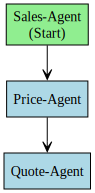

In [14]:
# Display the exported workflow SVG inline in the notebook

from IPython.display import SVG, display, HTML
import os

print(f"Attempting to display SVG file at: {svg_file}")

if svg_file and os.path.exists(svg_file):
    try:
        # Preferred: direct SVG rendering
        display(SVG(filename=svg_file))
    except Exception as e:
        print(f"⚠️ Direct SVG render failed: {e}. Falling back to raw HTML.")
        try:
            with open(svg_file, "r", encoding="utf-8") as f:
                svg_text = f.read()
            display(HTML(svg_text))
        except Exception as inner:
            print(f"❌ Fallback HTML render also failed: {inner}")
else:
    print("❌ SVG file not found. Ensure viz.export(format='svg') ran successfully.")

In [15]:
image_path = "../imgs/home.png"
with open(image_path, "rb") as image_file:
    image_b64 = base64.b64encode(image_file.read()).decode()
image_uri = f"data:image/png;base64,{image_b64}"


In [17]:
# Note: the original notebook used a multimodal ChatMessage with an image of a
# living room. The current Message class no longer ships TextContent/DataContent
# helpers, so this migration uses a textual description of the same scene to
# keep the lesson focused on sequential workflow mechanics.
message = Message(
    role="user",
    contents=[
        "I am furnishing a modern living room and want pieces that fit a warm, "
        "inviting style: a comfortable three-seat sofa, two accent armchairs, a "
        "wooden coffee table, a TV stand, a floor lamp, and a soft area rug. "
        "Please find appropriate furniture and give the corresponding price for "
        "each piece, then produce a final purchase quote."
    ],
)

In [18]:
# Workflow.run_stream is no longer part of the public API; the current Workflow
# returns a results object whose `get_outputs()` produces the AgentResponse from
# each output executor. The final stage (quote_agent) is the only output here.
events = await workflow.run(message)
outputs = events.get_outputs()
result = outputs[0].text if outputs else ""

In [19]:
result.replace("None", "")

'Great — I put together a cohesive mid-range warm-modern set (neutral tones, warm woods, tactile fabrics) that will make the living room feel inviting and contemporary. Prices are approximate market figures and exclude local sales tax; I included a modest delivery/assembly estimate. If you want, I can replace any piece with a higher- or lower-budget alternative.\n\nItemized recommendations (single cohesive look)\n- 3‑seat sofa — Performance-fabric, deep seat, tufted cushion, warm neutral (e.g., stone/greige velvet or performance linen)\n  - Description: 86" wide, removable cushions, sinuous-spring frame, kid-pet performance fabric\n  - Approx. price: $1,299\n\n- Accent armchair (x2) — Mid‑century/modern upholstered chairs in warm textured fabric\n  - Description: 1/2 tub or single-seat lounge chair, solid-wood legs in walnut tone, comfortable seat depth\n  - Approx. price: $499 each → $998 for two\n\n- Wooden coffee table — Solid or veneer oak rectangular coffee table, warm walnut/oak 